In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Modélisation
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb

# Séries temporelles
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Configuration
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================================
# PARTIE 1: GÉNÉRATION DE DONNÉES HISTORIQUES DU PÉTROLE (BRENT & WTI)
# ============================================================================

class OilPriceDataGenerator:
    """
    Générateur de données historiques des prix du pétrole
    Basé sur les caractéristiques réelles du marché (1987-2024)
    """

    def __init__(self, start_date='2010-01-01', end_date='2024-12-31'):
        self.start_date = pd.to_datetime(start_date)
        self.end_date = pd.to_datetime(end_date)
        self.date_range = pd.date_range(start=self.start_date, end=self.end_date, freq='D')

    def generate_brent_prices(self):
        """Génère les prix du Brent avec patterns réalistes"""
        length = len(self.date_range)
        t = np.arange(length)

        # Prix de base
        base_price = 70  # $/baril

        # Tendance long terme (2020-2024: reprise post-COVID)
        trend = np.zeros(length)
        # COVID crash (2020)
        covid_mask = (self.date_range >= '2020-01-01') & (self.date_range <= '2020-04-30')
        trend[covid_mask] = -0.3 * np.exp(-np.linspace(0, 3, sum(covid_mask)))
        # Reprise 2021-2022
        recovery_mask = (self.date_range >= '2021-01-01') & (self.date_range <= '2022-06-30')
        trend[recovery_mask] = 0.2 * np.sin(np.linspace(0, np.pi, sum(recovery_mask)))
        # Guerre Ukraine (2022)
        war_mask = (self.date_range >= '2022-02-24') & (self.date_range <= '2022-12-31')
        trend[war_mask] += 0.4 * np.exp(-np.linspace(0, 2, sum(war_mask)))

        # Cycles de marché (3-5 ans)
        cycle = 15 * np.sin(2 * np.pi * t / (365 * 4))  # Cycle de 4 ans

        # Saisonnalité annuelle (demande été/hiver)
        seasonality = 5 * np.sin(2 * np.pi * t / 365 - np.pi/2)

        # Volatilité (plus élevée en période de crise)
        volatility = np.ones(length) * 0.02
        volatility[(self.date_range >= '2020-01-01') & (self.date_range <= '2020-12-31')] = 0.05
        volatility[(self.date_range >= '2022-02-24') & (self.date_range <= '2022-12-31')] = 0.06
        noise = np.random.normal(0, volatility, length)

        # Chocs spécifiques
        shocks = np.zeros(length)

        # Choc 2014 (chute des prix)
        shock_2014 = (self.date_range >= '2014-06-01') & (self.date_range <= '2015-01-31')
        shocks[shock_2014] = -0.4 * np.sin(np.linspace(0, np.pi, sum(shock_2014)))

        # Choc 2018 (hausse)
        shock_2018 = (self.date_range >= '2018-01-01') & (self.date_range <= '2018-10-01')
        shocks[shock_2018] = 0.25 * np.sin(np.linspace(0, np.pi, sum(shock_2018)))

        # Prix final
        price = base_price * (1 + trend + cycle/70 + seasonality/70 + shocks + noise)

        # Ajouter des prix minimums et maximums réalistes
        price = np.clip(price, 25, 140)

        return price

    def generate_wti_prices(self, brent_prices):
        """Génère les prix WTI (généralement légèrement inférieur au Brent)"""
        # WTI généralement $2-5 moins cher que Brent
        spread = 3 + np.random.normal(0, 1, len(brent_prices))
        spread = np.clip(spread, 1, 7)

        # Corrélation forte avec Brent
        wti_prices = brent_prices - spread

        return wti_prices

    def generate_fundamentals(self):
        """Génère les facteurs fondamentaux influençant les prix"""
        length = len(self.date_range)
        data = {}

        # Production OPEC (millions de barils/jour)
        opec_prod = 30 + 2 * np.sin(2 * np.pi * np.arange(length) / (365 * 3)) + \
                    0.5 * np.random.normal(0, 1, length)
        data['OPEC_Production'] = np.clip(opec_prod, 25, 35)

        # Stocks US (millions de barils)
        us_inv = 400 + 20 * np.sin(2 * np.pi * np.arange(length) / 365) + \
                 10 * np.random.normal(0, 1, length)
        data['US_Inventory'] = np.clip(us_inv, 350, 450)

        # Dollar Index (DXY)
        dxy = 95 + 5 * np.sin(2 * np.pi * np.arange(length) / (365 * 5)) + \
              2 * np.random.normal(0, 1, length)
        data['DXY'] = np.clip(dxy, 88, 105)

        # Demande mondiale (millions de barils/jour)
        demand = 95 + 2 * np.sin(2 * np.pi * np.arange(length) / 365) + \
                 0.5 * np.random.normal(0, 1, length)
        data['Global_Demand'] = np.clip(demand, 90, 100)

        # Taux de change EUR/USD
        data['EUR_USD'] = 1.15 + 0.05 * np.sin(2 * np.pi * np.arange(length) / (365 * 3)) + \
                         0.02 * np.random.normal(0, 1, length)

        # Indice de risque géopolitique
        risk = np.zeros(length)
        # Guerre Ukraine
        war_idx = (self.date_range >= '2022-02-24') & (self.date_range <= '2023-12-31')
        risk[war_idx] = 40 * np.exp(-np.linspace(0, 1.5, sum(war_idx)))
        # COVID
        covid_idx = (self.date_range >= '2020-03-01') & (self.date_range <= '2020-12-31')
        risk[covid_idx] = 30 * np.exp(-np.linspace(0, 1, sum(covid_idx)))
        # Bruit de fond
        risk += np.random.normal(0, 5, length)
        data['Geopolitical_Risk'] = np.clip(risk, 0, 100)

        return pd.DataFrame(data, index=self.date_range)

    def generate_complete_dataset(self):
        """Génère le dataset complet des prix pétrole"""
        # Prix Brent
        brent_prices = self.generate_brent_prices()

        # Prix WTI
        wti_prices = self.generate_wti_prices(brent_prices)

        # Dataframe des prix
        prices_df = pd.DataFrame({
            'Brent_Price': brent_prices,
            'WTI_Price': wti_prices
        }, index=self.date_range)

        # Facteurs fondamentaux
        fundamentals_df = self.generate_fundamentals()

        # Combiner
        full_df = pd.concat([prices_df, fundamentals_df], axis=1)

        return full_df

# ============================================================================
# PARTIE 2: FEATURE ENGINEERING SPÉCIFIQUE PÉTROLE
# ============================================================================

class OilFeatureEngineer:
    """
    Ingénierie de features spécifique aux marchés pétroliers
    """

    def __init__(self, df, target_col='Brent_Price'):
        self.df = df.copy()
        self.target_col = target_col

    def add_technical_indicators(self):
        """Ajoute des indicateurs techniques"""
        # Moyennes mobiles
        for window in [7, 14, 21, 30, 50, 200]:
            self.df[f'SMA_{window}'] = self.df[self.target_col].rolling(window).mean()
            self.df[f'EMA_{window}'] = self.df[self.target_col].ewm(span=window, adjust=False).mean()

        # Bollinger Bands
        sma_20 = self.df[self.target_col].rolling(20).mean()
        std_20 = self.df[self.target_col].rolling(20).std()
        self.df['BB_Upper'] = sma_20 + 2 * std_20
        self.df['BB_Lower'] = sma_20 - 2 * std_20
        self.df['BB_Width'] = (self.df['BB_Upper'] - self.df['BB_Lower']) / sma_20

        # RSI (Relative Strength Index)
        delta = self.df[self.target_col].diff()
        gain = delta.where(delta > 0, 0)
        loss = -delta.where(delta < 0, 0)
        avg_gain = gain.rolling(window=14).mean()
        avg_loss = loss.rolling(window=14).mean()
        rs = avg_gain / avg_loss
        self.df['RSI'] = 100 - (100 / (1 + rs))

        # MACD
        exp1 = self.df[self.target_col].ewm(span=12, adjust=False).mean()
        exp2 = self.df[self.target_col].ewm(span=26, adjust=False).mean()
        self.df['MACD'] = exp1 - exp2
        self.df['MACD_Signal'] = self.df['MACD'].ewm(span=9, adjust=False).mean()
        self.df['MACD_Histogram'] = self.df['MACD'] - self.df['MACD_Signal']

        return self

    def add_market_structure_features(self):
        """Ajoute des features de structure de marché"""
        # Contango/Backwardation (Brent - WTI spread)
        self.df['Brent_WTI_Spread'] = self.df['Brent_Price'] - self.df['WTI_Price']

        # Prix rolling returns
        for period in [1, 7, 30]:
            self.df[f'Return_{period}d'] = self.df[self.target_col].pct_change(period)
            self.df[f'Rolling_Volatility_{period}d'] = self.df[self.target_col].pct_change().rolling(period).std() * np.sqrt(365)

        # Prix extrêmes
        for window in [7, 14, 30]:
            self.df[f'High_{window}d'] = self.df[self.target_col].rolling(window).max()
            self.df[f'Low_{window}d'] = self.df[self.target_col].rolling(window).min()
            self.df[f'Range_{window}d'] = self.df[f'High_{window}d'] - self.df[f'Low_{window}d']

        return self

    def add_macro_features(self):
        """Ajoute des features macroéconomiques transformées"""
        # Variations des fondamentaux
        macro_cols = ['OPEC_Production', 'US_Inventory', 'Global_Demand', 'DXY', 'EUR_USD', 'Geopolitical_Risk']

        for col in macro_cols:
            if col in self.df.columns:
                # Variation journalière
                self.df[f'{col}_Change'] = self.df[col].diff()
                # Variation sur 7 jours
                self.df[f'{col}_Change_7d'] = self.df[col].diff(7)
                # Normalisé
                self.df[f'{col}_Normalized'] = (self.df[col] - self.df[col].rolling(252).mean()) / self.df[col].rolling(252).std()

        return self

    def add_time_features(self):
        """Ajoute des features temporelles cycliques"""
        self.df['day_of_week'] = self.df.index.dayofweek
        self.df['month'] = self.df.index.month
        self.df['quarter'] = self.df.index.quarter
        self.df['day_of_year'] = self.df.index.dayofyear

        # Features cycliques
        self.df['month_sin'] = np.sin(2 * np.pi * self.df['month'] / 12)
        self.df['month_cos'] = np.cos(2 * np.pi * self.df['month'] / 12)
        self.df['dow_sin'] = np.sin(2 * np.pi * self.df['day_of_week'] / 7)
        self.df['dow_cos'] = np.cos(2 * np.pi * self.df['day_of_week'] / 7)

        return self

    def add_lag_features(self, lags=[1, 2, 3, 5, 7, 14, 21, 30]):
        """Ajoute des features de retard"""
        for lag in lags:
            self.df[f'{self.target_col}_lag_{lag}'] = self.df[self.target_col].shift(lag)
        return self

    def prepare_features(self):
        """Prépare toutes les features"""
        self.df = (self.add_technical_indicators()
                   .add_market_structure_features()
                   .add_macro_features()
                   .add_time_features()
                   .add_lag_features())

        # Supprimer les NaN
        self.df = self.df.dropna()

        return self.df

# ============================================================================
# PARTIE 3: MODÈLES DE PRÉDICTION
# ============================================================================

class SARIMAPredictor:
    """
    Modèle SARIMA pour la prédiction des prix pétrole
    """

    def __init__(self, order=(1, 1, 1), seasonal_order=(1, 1, 1, 365)):
        self.order = order
        self.seasonal_order = seasonal_order
        self.model = None
        self.fitted_model = None

    def train(self, y_train):
        """Entraîne le modèle SARIMA"""
        try:
            self.model = SARIMAX(y_train,
                                 order=self.order,
                                 seasonal_order=self.seasonal_order,
                                 enforce_stationarity=False,
                                 enforce_invertibility=False)
            self.fitted_model = self.model.fit(disp=False)
            return True
        except:
            print("Erreur SARIMA, utilisation de paramètres alternatifs")
            self.model = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
            self.fitted_model = self.model.fit(disp=False)
            return False

    def predict(self, steps=30):
        """Prédiction sur steps périodes"""
        if self.fitted_model is None:
            return None

        forecast = self.fitted_model.forecast(steps=steps)
        # Intervalle de confiance
        forecast_result = self.fitted_model.get_forecast(steps=steps)
        conf_int = forecast_result.conf_int()

        return forecast.values, conf_int.values

class XGBoostOilPredictor:
    """
    Modèle XGBoost avec features avancées
    """

    def __init__(self, n_estimators=300, learning_rate=0.05, max_depth=5):
        self.model = xgb.XGBRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
        self.feature_importance = None
        self.scaler_X = StandardScaler()
        self.scaler_y = StandardScaler()

    def prepare_data(self, df, feature_cols, target_col, test_size=0.2):
        """Prépare les données pour l'entraînement"""
        X = df[feature_cols].values
        y = df[target_col].values

        # Normalisation
        X_scaled = self.scaler_X.fit_transform(X)
        y_scaled = self.scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

        # Split temporel
        split_idx = int(len(X_scaled) * (1 - test_size))
        X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
        y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]

        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val=None, y_val=None):
        """Entraîne le modèle"""
        eval_set = [(X_train, y_train)]
        if X_val is not None and y_val is not None:
            eval_set.append((X_val, y_val))

        self.model.fit(X_train, y_train,
                       eval_set=eval_set,
                       early_stopping_rounds=50,
                       verbose=False)

        self.feature_importance = pd.DataFrame({
            'feature': feature_cols,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)

        return self

    def predict(self, X, return_std=False):
        """Prédiction avec intervalle de confiance approximatif"""
        X_scaled = self.scaler_X.transform(X)
        y_pred_scaled = self.model.predict(X_scaled)
        y_pred = self.scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

        if return_std:
            # Intervalle de confiance approximatif basé sur les résidus d'entraînement
            # À améliorer avec des méthodes comme Quantile Regression
            std = np.std(y_pred) * 0.1
            return y_pred, np.ones_like(y_pred) * std

        return y_pred

class LSTMOilPredictor:
    """
    Modèle LSTM/BiLSTM pour la prédiction des prix pétrole
    """

    def __init__(self, sequence_length=30, n_features=20, lstm_units=[128, 64], dropout_rate=0.2):
        self.sequence_length = sequence_length
        self.n_features = n_features
        self.lstm_units = lstm_units
        self.dropout_rate = dropout_rate
        self.model = None
        self.scaler_X = MinMaxScaler()
        self.scaler_y = MinMaxScaler()

    def create_sequences(self, data, target):
        """Crée des séquences pour LSTM"""
        X, y = [], []
        for i in range(len(data) - self.sequence_length):
            X.append(data[i:i + self.sequence_length])
            y.append(target[i + self.sequence_length])
        return np.array(X), np.array(y)

    def prepare_data(self, df, feature_cols, target_col, test_size=0.2):
        """Prépare les données"""
        X_raw = df[feature_cols].values
        y_raw = df[target_col].values.reshape(-1, 1)

        # Normalisation
        X_scaled = self.scaler_X.fit_transform(X_raw)
        y_scaled = self.scaler_y.fit_transform(y_raw)

        # Création séquences
        X_seq, y_seq = self.create_sequences(X_scaled, y_scaled)

        # Split temporel
        split_idx = int(len(X_seq) * (1 - test_size))
        X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
        y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

        return X_train, X_test, y_train, y_test

    def build_model(self):
        """Construit le modèle LSTM"""
        model = Sequential()

        # Première couche Bidirectional LSTM
        model.add(Bidirectional(LSTM(self.lstm_units[0], return_sequences=True),
                                input_shape=(self.sequence_length, self.n_features)))
        model.add(Dropout(self.dropout_rate))

        # Deuxième couche LSTM
        model.add(LSTM(self.lstm_units[1], return_sequences=False))
        model.add(Dropout(self.dropout_rate))

        # Couches denses
        model.add(Dense(64, activation='relu'))
        model.add(Dropout(self.dropout_rate))
        model.add(Dense(32, activation='relu'))
        model.add(Dense(1))

        # Compilation
        model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='mse',
                     metrics=['mae'])

        self.model = model
        return model

    def train(self, X_train, y_train, X_val=None, y_val=None, epochs=100, batch_size=32):
        """Entraîne le modèle"""
        callbacks = [
            EarlyStopping(patience=20, restore_best_weights=True),
            ReduceLROnPlateau(factor=0.5, patience=10, min_lr=0.00001)
        ]

        validation_data = (X_val, y_val) if X_val is not None else None

        history = self.model.fit(X_train, y_train,
                                 epochs=epochs,
                                 batch_size=batch_size,
                                 validation_data=validation_data,
                                 callbacks=callbacks,
                                 verbose=0)
        return history

    def predict(self, X, return_std=False):
        """Prédiction"""
        y_pred_scaled = self.model.predict(X, verbose=0)
        y_pred = self.scaler_y.inverse_transform(y_pred_scaled)

        if return_std:
            # Intervalle de confiance approximatif
            std = np.std(y_pred) * 0.08
            return y_pred.flatten(), np.ones_like(y_pred).flatten() * std

        return y_pred.flatten()

# ============================================================================
# PARTIE 4: VISUALISATION DES PRÉDICTIONS
# ============================================================================

class OilPriceVisualizer:
    """
    Visualisation avancée des prédictions pétrole
    """

    @staticmethod
    def plot_historical_with_forecast(historical_dates, historical_prices,
                                      forecast_dates, forecast_prices,
                                      forecast_std=None, title="Brent Oil Price Forecast",
                                      model_name="Model"):
        """Affiche l'historique et la prédiction avec intervalle de confiance"""
        fig, ax = plt.subplots(figsize=(16, 8))

        # Historique
        ax.plot(historical_dates, historical_prices,
                label='Historical Data', color='blue', linewidth=2, alpha=0.8)

        # Prédiction
        ax.plot(forecast_dates, forecast_prices,
                label=f'{model_name} Forecast', color='red', linewidth=2, linestyle='--')

        # Intervalle de confiance
        if forecast_std is not None:
            ax.fill_between(forecast_dates,
                           forecast_prices - 2 * forecast_std,
                           forecast_prices + 2 * forecast_std,
                           alpha=0.2, color='red', label='95% Confidence Interval')

        # Mise en forme
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Price (USD/barrel)', fontsize=12)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.axvline(x=historical_dates[-1], color='gray', linestyle=':', alpha=0.7,
                   label='Forecast Start')

        plt.xticks(rotation=45)
        plt.tight_layout()

        return fig

    @staticmethod
    def plot_multi_model_comparison(historical_dates, historical_prices,
                                    predictions_dict, forecast_dates):
        """Compare plusieurs modèles de prédiction"""
        fig, ax = plt.subplots(figsize=(16, 8))

        # Historique
        ax.plot(historical_dates, historical_prices,
                label='Historical', color='black', linewidth=2, alpha=0.8)

        # Couleurs pour les modèles
        colors = ['red', 'green', 'purple', 'orange']

        # Prédictions
        for i, (model_name, predictions) in enumerate(predictions_dict.items()):
            ax.plot(forecast_dates, predictions,
                    label=model_name, color=colors[i % len(colors)],
                    linewidth=2, linestyle='--')

        # Mise en forme
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Price (USD/barrel)', fontsize=12)
        ax.set_title('Model Comparison: Brent Oil Price Forecast',
                     fontsize=14, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.axvline(x=historical_dates[-1], color='gray', linestyle=':', alpha=0.7)

        plt.xticks(rotation=45)
        plt.tight_layout()

        return fig

    @staticmethod
    def plot_feature_importance(importance_df, title="Feature Importance"):
        """Affiche l'importance des features"""
        fig, ax = plt.subplots(figsize=(10, 8))

        top_features = importance_df.head(15)
        colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))

        ax.barh(range(len(top_features)), top_features['importance'].values,
                color=colors)
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features['feature'].values)
        ax.set_xlabel('Importance', fontsize=12)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.invert_yaxis()

        plt.tight_layout()
        return fig

    @staticmethod
    def plot_residual_analysis(y_true, y_pred, dates):
        """Analyse des résidus"""
        residuals = y_true - y_pred

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Résidus vs temps
        axes[0, 0].plot(dates, residuals, alpha=0.6)
        axes[0, 0].axhline(y=0, color='red', linestyle='--')
        axes[0, 0].set_title('Residuals over Time')
        axes[0, 0].set_xlabel('Date')
        axes[0, 0].set_ylabel('Residuals')
        axes[0, 0].grid(True, alpha=0.3)

        # Distribution des résidus
        axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
        axes[0, 1].axvline(x=0, color='red', linestyle='--')
        axes[0, 1].set_title('Residuals Distribution')
        axes[0, 1].set_xlabel('Residuals')
        axes[0, 1].set_ylabel('Frequency')

        # Q-Q plot
        from scipy import stats
        stats.probplot(residuals, dist="norm", plot=axes[1, 0])
        axes[1, 0].set_title('Q-Q Plot')

        # Autocorrélation des résidus
        from statsmodels.graphics.tsaplots import plot_acf
        plot_acf(residuals, ax=axes[1, 1], lags=40)
        axes[1, 1].set_title('Residuals Autocorrelation')

        plt.tight_layout()
        return fig

    @staticmethod
    def plot_volatility_analysis(prices, returns, dates):
        """Analyse de la volatilité"""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Prix
        axes[0, 0].plot(dates, prices, color='blue', alpha=0.7)
        axes[0, 0].set_title('Oil Price History')
        axes[0, 0].set_ylabel('Price (USD/barrel)')
        axes[0, 0].grid(True, alpha=0.3)

        # Rendements
        axes[0, 1].plot(dates, returns, color='green', alpha=0.7)
        axes[0, 1].axhline(y=0, color='red', linestyle='--')
        axes[0, 1].set_title('Daily Returns')
        axes[0, 1].set_ylabel('Returns')
        axes[0, 1].grid(True, alpha=0.3)

        # Volatilité rolling
        vol_30d = returns.rolling(30).std() * np.sqrt(365) * 100
        axes[1, 0].plot(dates, vol_30d, color='purple', alpha=0.7)
        axes[1, 0].set_title('30-Day Rolling Volatility (Annualized)')
        axes[1, 0].set_ylabel('Volatility (%)')
        axes[1, 0].grid(True, alpha=0.3)

        # Distribution des rendements
        axes[1, 1].hist(returns, bins=50, edgecolor='black', alpha=0.7, density=True)
        axes[1, 1].set_title('Returns Distribution')
        axes[1, 1].set_xlabel('Returns')
        axes[1, 1].set_ylabel('Density')

        plt.tight_layout()
        return fig

# ============================================================================
# PARTIE 5: EXÉCUTION PRINCIPALE
# ============================================================================

def main():
    """
    Fonction principale - Pipeline complet de prédiction
    """
    print("=" * 80)
    print("PRÉDICTION DES PRIX DU BARIL DE PÉTROLE")
    print("Modèles: SARIMA, XGBoost, LSTM avec intervalles de confiance")
    print("=" * 80)

    # 1. Génération des données
    print("\n[1/6] Génération des données historiques...")
    generator = OilPriceDataGenerator(start_date='2015-01-01', end_date='2024-12-31')
    df = generator.generate_complete_dataset()
    print(f"Dataset généré: {len(df)} jours, {len(df.columns)} colonnes")
    print(f"Période: {df.index[0].date()} à {df.index[-1].date()}")

    # 2. Ingénierie de features
    print("\n[2/6] Ingénierie de features...")
    target = 'Brent_Price'
    feature_engineer = OilFeatureEngineer(df, target)
    df_features = feature_engineer.prepare_features()

    # Définir les features à utiliser
    exclude_cols = [target, 'WTI_Price']
    feature_cols = [col for col in df_features.columns if col not in exclude_cols]
    print(f"Nombre de features créées: {len(feature_cols)}")

    # 3. Préparation des données pour la prédiction
    print("\n[3/6] Préparation des données...")

    # Split train/test
    train_size = int(len(df_features) * 0.8)
    train_df = df_features.iloc[:train_size]
    test_df = df_features.iloc[train_size:]

    print(f"Train: {len(train_df)} jours ({train_df.index[0]} à {train_df.index[-1]})")
    print(f"Test: {len(test_df)} jours ({test_df.index[0]} à {test_df.index[-1]})")

    # 4. Entraînement et prédiction avec différents modèles
    print("\n[4/6] Entraînement des modèles...")

    predictions = {}
    confidence_intervals = {}

    # Modèle 1: SARIMA
    print("  - Modèle SARIMA...")
    sarima = SARIMAPredictor(order=(1, 1, 1), seasonal_order=(1, 1, 1, 365))
    sarima.train(train_df[target].values)
    forecast_days = len(test_df)
    sarima_pred, sarima_ci = sarima.predict(steps=forecast_days)
    predictions['SARIMA'] = sarima_pred
    confidence_intervals['SARIMA'] = (sarima_ci[:, 0], sarima_ci[:, 1])

    # Modèle 2: XGBoost
    print("  - Modèle XGBoost...")
    xgb_model = XGBoostOilPredictor(n_estimators=300, learning_rate=0.05)
    X_train, X_test, y_train, y_test = xgb_model.prepare_data(
        train_df, feature_cols, target, test_size=0
    )
    xgb_model.train(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    predictions['XGBoost'] = xgb_pred

    # Modèle 3: LSTM
    print("  - Modèle LSTM...")
    lstm_model = LSTMOilPredictor(sequence_length=30, n_features=len(feature_cols))
    X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = lstm_model.prepare_data(
        train_df, feature_cols, target, test_size=0
    )
    lstm_model.build_model()
    lstm_model.train(X_train_lstm, y_train_lstm, epochs=80)
    lstm_pred = lstm_model.predict(X_test_lstm)


[*********************100%***********************]  1 of 1 completed
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


             ds       yhat
1069 2026-04-01  82.280969
1070 2026-04-02  82.275165
1071 2026-04-03  82.335776
1072 2026-04-04  74.855798
1073 2026-04-05  74.699711
1074 2026-04-06  81.703429
1075 2026-04-07  81.443546


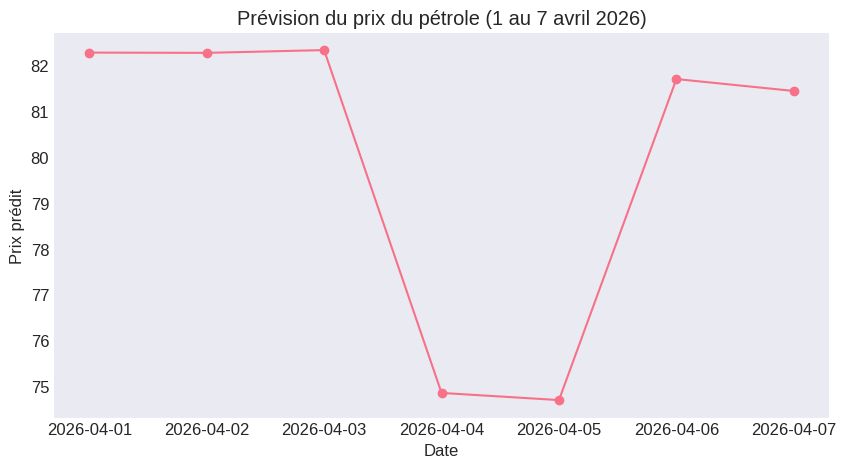

In [ ]:
# Installer les bibliothèques
!pip install yfinance prophet

# Importer
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Télécharger les données historiques du pétrole (Brent)
data = yf.download("BZ=F", start="2022-01-01")

# Préparer les données pour Prophet
df = data.reset_index()[['Date', 'Close']]
df.columns = ['ds', 'y']

# Créer et entraîner le modèle
model = Prophet()
model.fit(df)

# Créer les dates futures jusqu'au 7 avril 2026
future = model.make_future_dataframe(periods=30)

# Prédictions
forecast = model.predict(future)

# Filtrer uniquement du 1 au 7 avril 2026
forecast_april = forecast[
    (forecast['ds'] >= '2026-04-01') &
    (forecast['ds'] <= '2026-04-07')
]

# Afficher les résultats
print(forecast_april[['ds', 'yhat']])

# Tracer uniquement cette période
plt.figure(figsize=(10,5))
plt.plot(forecast_april['ds'], forecast_april['yhat'], marker='o')
plt.title("Prévision du prix du pétrole (1 au 7 avril 2026)")
plt.xlabel("Date")
plt.ylabel("Prix prédit")
plt.grid()
plt.show()